# 🍽️ Zomato Restaurant Rating Analyzer
### Exploratory Data Analysis, Correlation Study & Insights

**Dataset:** Zomato Bangalore Restaurants — [Kaggle Link](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants)

**Concepts Applied:**
- Data Preprocessing & Cleaning (like Lab A3, A4)
- Handling Missing Values
- Exploratory Data Analysis (EDA)
- Correlation Analysis (like Lab A8)
- Data Visualization using Matplotlib & Seaborn
- Grouping & Aggregate Statistics (like Lab A3)

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## 📂 Step 2: Load the Dataset

> **Download the dataset from Kaggle:**  
> https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants  
> Place the file `zomato.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv(r"C:\Users\MA551WS\Desktop\zomato.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
df.head()

Dataset Shape: (51717, 17)

Column Names:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


## 🔍 Step 3: Initial Data Exploration

In [3]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_li

In [4]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

=== Missing Values ===


,Missing Count,Missing %
dish_liked,28078,54.291626
rate,7775,15.033741
phone,1208,2.335789
approx_cost(for two people),346,0.669026
rest_type,227,0.438927
cuisines,45,0.087012
location,21,0.040606


In [5]:
print("=== Basic Statistics ===")
df.describe(include='all')

=== Basic Statistics ===


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,51717.000000,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,NaN,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/jalsa-banasha...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,NaN,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,NaN,216,5124,19132,182,2913,7576,7595,39617,25942,3279
mean,NaN,NaN,NaN,NaN,NaN,NaN,283.697527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,803.838853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,198.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🧹 Step 4: Data Preprocessing & Cleaning

In [6]:
# --- 4.1: Clean the 'rate' column (e.g., '4.1/5' → 4.1) ---
def clean_rate(value):
    try:
        value = str(value).strip()
        if value in ['NEW', '-', 'nan']:
            return np.nan
        return float(value.split('/')[0])
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)

# --- 4.2: Clean 'approx_cost(for two people)' ---
df['cost'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').str.strip()
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# --- 4.3: Clean 'votes' ---
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# --- 4.4: Drop duplicates ---
df.drop_duplicates(inplace=True)

# --- 4.5: Drop rows where rate is missing (target variable) ---
df.dropna(subset=['rate'], inplace=True)

# --- 4.6: Fill remaining missing values ---
df['cost'].fillna(df['cost'].median(), inplace=True)
df['cuisines'].fillna('Unknown', inplace=True)

# --- 4.7: Rename for convenience ---
df.rename(columns={
    'listed_in(type)': 'restaurant_type',
    'listed_in(city)': 'city'
}, inplace=True)

print(f"Cleaned Dataset Shape: {df.shape}")
df[['name', 'rate', 'votes', 'cost', 'restaurant_type', 'location']].head()

Cleaned Dataset Shape: (41665, 18)


,name,rate,votes,cost,restaurant_type,location
0,Jalsa,4.1,775,800.0,Buffet,Banashankari
1,Spice Elephant,4.1,787,800.0,Buffet,Banashankari
2,San Churro Cafe,3.8,918,800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,3.7,88,300.0,Buffet,Banashankari
4,Grand Village,3.8,166,600.0,Buffet,Basavanagudi


## 📊 Step 5: Exploratory Data Analysis (EDA)

### 5.1 — Distribution of Restaurant Ratings

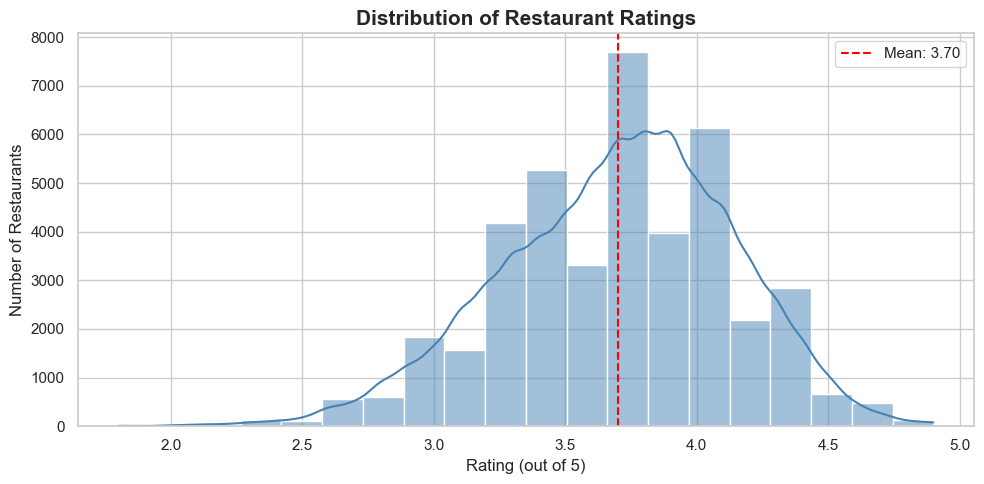

Mean Rating   : 3.70
Median Rating : 3.70
Std Dev       : 0.44


In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['rate'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Restaurant Ratings', fontsize=15, fontweight='bold')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Restaurants')
plt.axvline(df['rate'].mean(), color='red', linestyle='--', label=f"Mean: {df['rate'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()
print(f"Mean Rating   : {df['rate'].mean():.2f}")
print(f"Median Rating : {df['rate'].median():.2f}")
print(f"Std Dev       : {df['rate'].std():.2f}")

### 5.2 — Online Order vs Rating

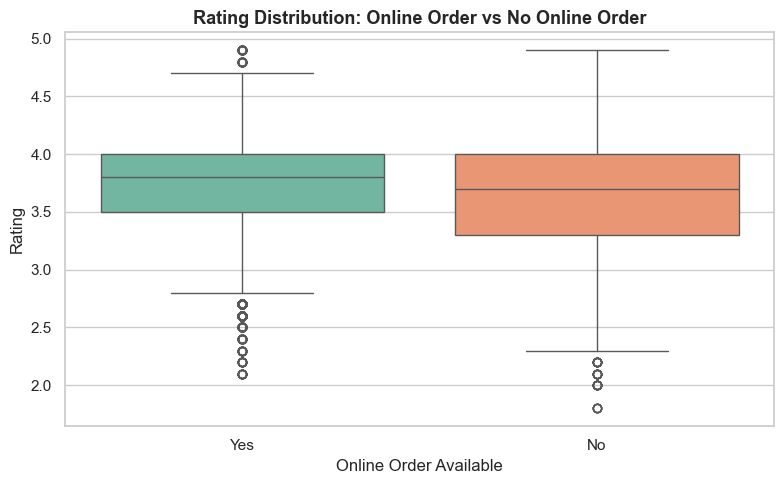

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')
plt.title('Rating Distribution: Online Order vs No Online Order', fontsize=13, fontweight='bold')
plt.xlabel('Online Order Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('online_order_vs_rating.png', dpi=150)
plt.show()

### 5.3 — Table Booking vs Rating

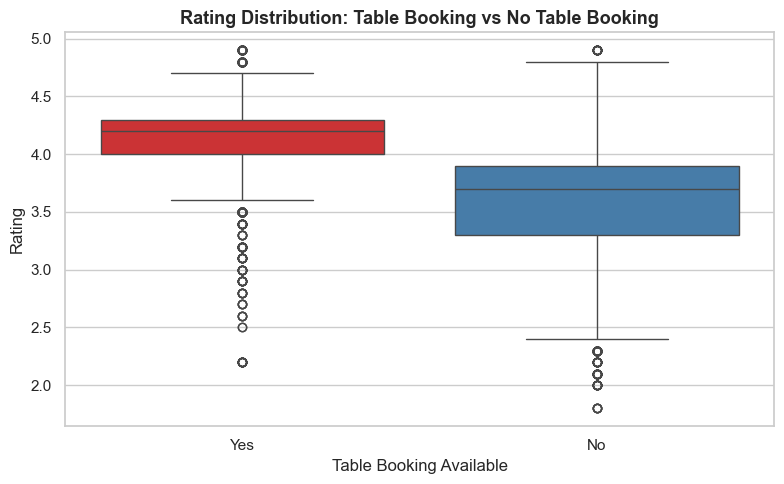

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='book_table', y='rate', data=df, palette='Set1')
plt.title('Rating Distribution: Table Booking vs No Table Booking', fontsize=13, fontweight='bold')
plt.xlabel('Table Booking Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('table_booking_vs_rating.png', dpi=150)
plt.show()

### 5.4 — Top 10 Locations by Number of Restaurants

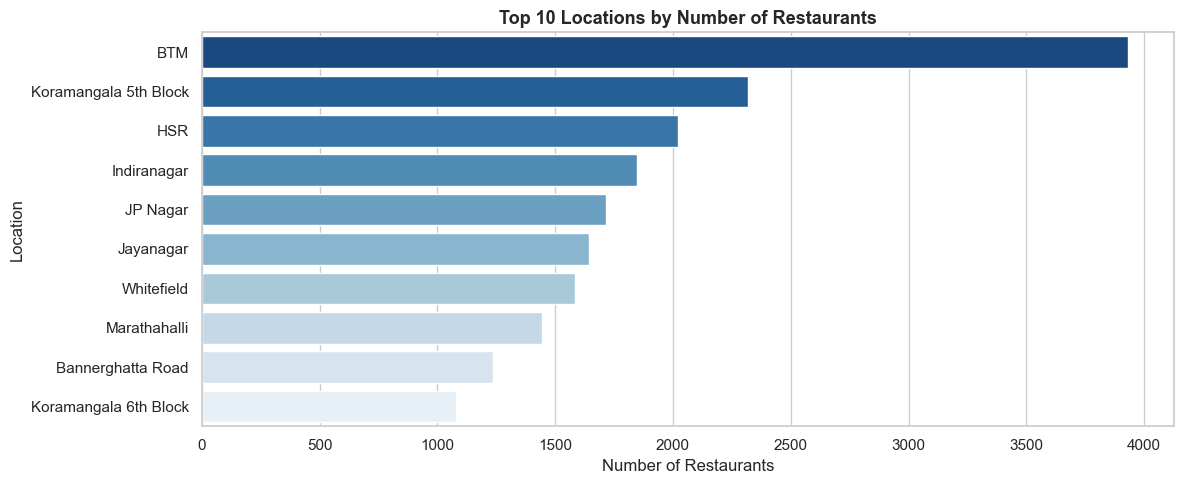

In [10]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Blues_r')
plt.title('Top 10 Locations by Number of Restaurants', fontsize=13, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

### 5.5 — Average Rating by Restaurant Type

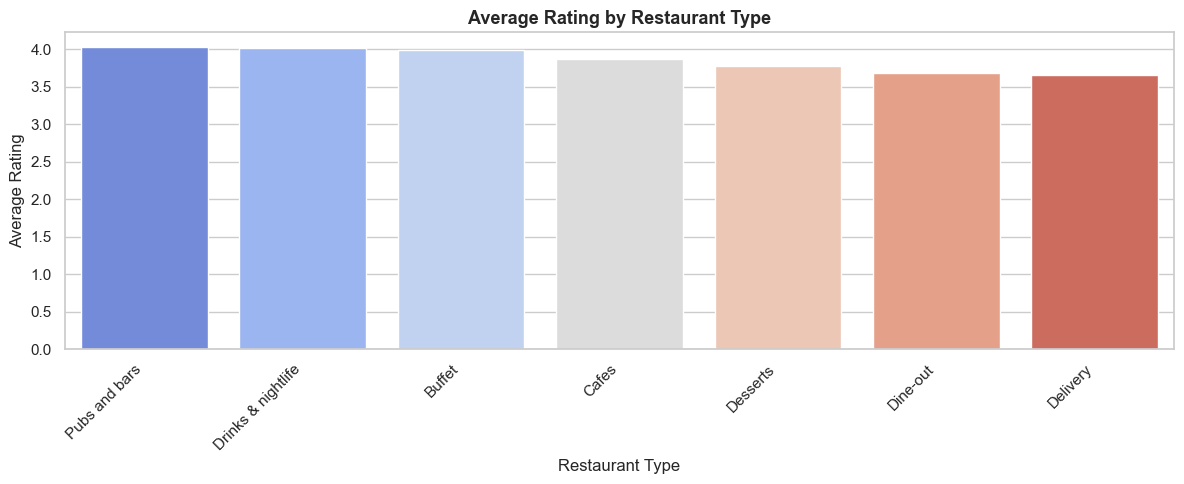

In [11]:
avg_rating_type = df.groupby('restaurant_type')['rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_rating_type.index, y=avg_rating_type.values, palette='coolwarm')
plt.title('Average Rating by Restaurant Type', fontsize=13, fontweight='bold')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('avg_rating_by_type.png', dpi=150)
plt.show()

### 5.6 — Cost Distribution

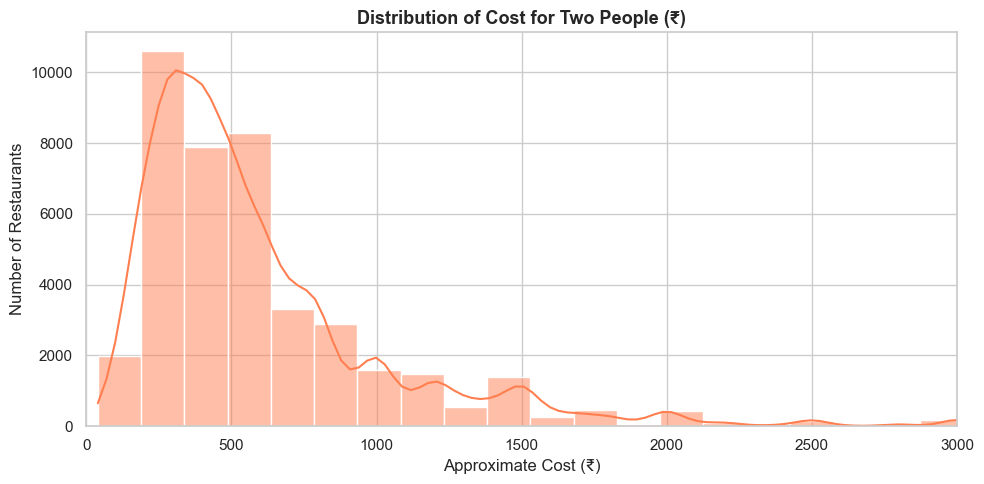

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['cost'], bins=40, kde=True, color='coral')
plt.title('Distribution of Cost for Two People (₹)', fontsize=13, fontweight='bold')
plt.xlabel('Approximate Cost (₹)')
plt.ylabel('Number of Restaurants')
plt.xlim(0, 3000)
plt.tight_layout()
plt.savefig('cost_distribution.png', dpi=150)
plt.show()

## 📈 Step 6: Aggregate Statistics (Grouping)

In [13]:
print("=== Aggregate Statistics by Restaurant Type ===")
agg_stats = df.groupby('restaurant_type').agg(
    Count=('name', 'count'),
    Avg_Rating=('rate', 'mean'),
    Min_Rating=('rate', 'min'),
    Max_Rating=('rate', 'max'),
    Avg_Cost=('cost', 'mean'),
    Total_Votes=('votes', 'sum')
).round(2).sort_values('Count', ascending=False)

print(agg_stats)

=== Aggregate Statistics by Restaurant Type ===
                    Count  Avg_Rating  Min_Rating  Max_Rating  Avg_Cost  \
restaurant_type                                                           
Delivery            20649        3.65         2.0         4.9    495.18   
Dine-out            14207        3.68         1.8         4.9    653.70   
Desserts             2732        3.78         2.4         4.9    409.49   
Cafes                1526        3.87         2.3         4.7    644.99   
Drinks & nightlife   1055        4.02         2.0         4.9   1445.73   
Buffet                855        3.98         2.3         4.9   1309.94   
Pubs and bars         641        4.02         2.4         4.9   1324.96   

                    Total_Votes  
restaurant_type                  
Delivery                5291001  
Dine-out                5135243  
Desserts                 541294  
Cafes                    826857  
Drinks & nightlife      1262257  
Buffet                   889438  
Pubs

In [14]:
print("=== Top 10 Locations by Average Rating ===")
location_stats = df.groupby('location').agg(
    Count=('name', 'count'),
    Avg_Rating=('rate', 'mean')
).round(2)

# Filter locations with at least 10 restaurants for fairness
location_stats = location_stats[location_stats['Count'] >= 10]
print(location_stats.sort_values('Avg_Rating', ascending=False).head(10))

=== Top 10 Locations by Average Rating ===
                       Count  Avg_Rating
location                                
Lavelle Road             487        4.14
St. Marks Road           343        4.02
Koramangala 3rd Block    191        4.02
Koramangala 5th Block   2319        4.01
Church Street            546        3.99
Sankey Road               26        3.97
Koramangala 4th Block    841        3.92
Cunningham Road          475        3.90
MG Road                  811        3.86
Residency Road           605        3.86


## 🔗 Step 7: Correlation Analysis

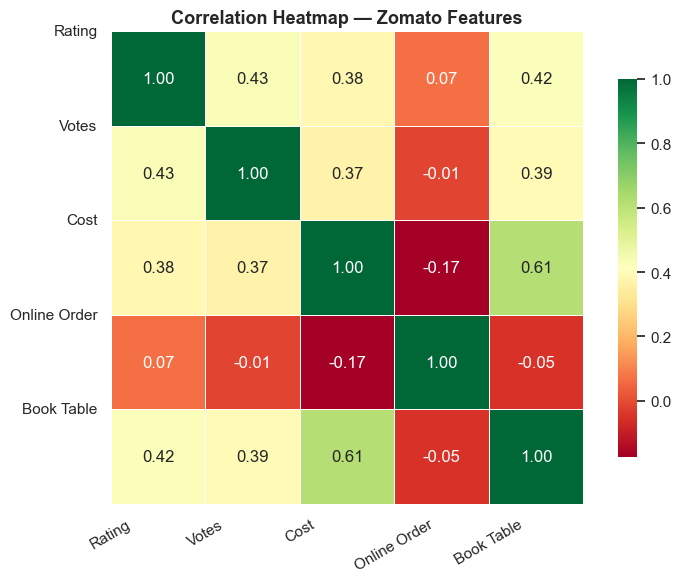


=== Correlation with Rating ===
rate                1.000000
votes               0.434040
book_table_enc      0.424631
cost                0.384042
online_order_enc    0.068479
Name: rate, dtype: float64


In [15]:
# Encode binary columns for correlation
df_corr = df.copy()
df_corr['online_order_enc'] = (df_corr['online_order'] == 'Yes').astype(int)
df_corr['book_table_enc'] = (df_corr['book_table'] == 'Yes').astype(int)

corr_cols = ['rate', 'votes', 'cost', 'online_order_enc', 'book_table_enc']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Zomato Features', fontsize=13, fontweight='bold')
plt.xticks(ticks=range(len(corr_cols)), labels=['Rating', 'Votes', 'Cost', 'Online Order', 'Book Table'], rotation=30)
plt.yticks(ticks=range(len(corr_cols)), labels=['Rating', 'Votes', 'Cost', 'Online Order', 'Book Table'], rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\n=== Correlation with Rating ===")
print(corr_matrix['rate'].sort_values(ascending=False))

### 7.1 — Scatter: Cost vs Rating

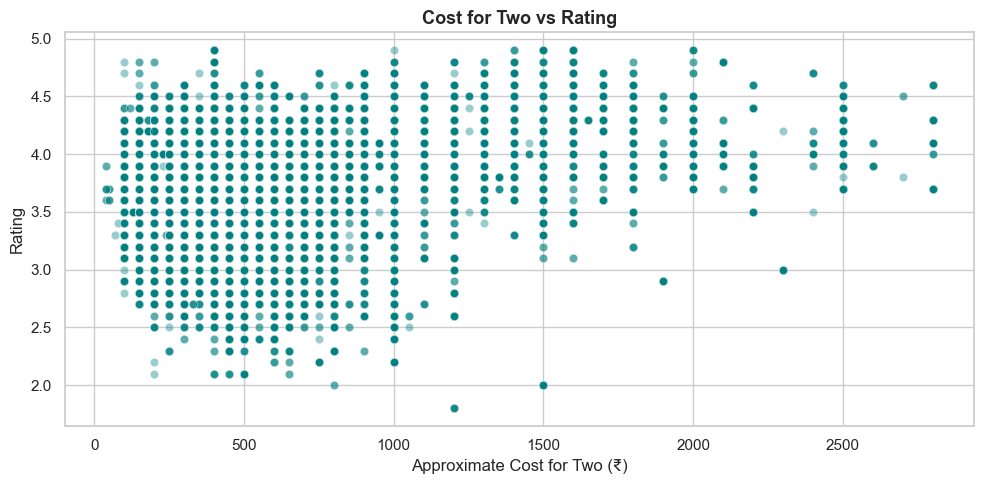

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='cost', y='rate', data=df[df['cost'] < 3000], alpha=0.4, color='teal')
plt.title('Cost for Two vs Rating', fontsize=13, fontweight='bold')
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('cost_vs_rating.png', dpi=150)
plt.show()

### 7.2 — Votes vs Rating

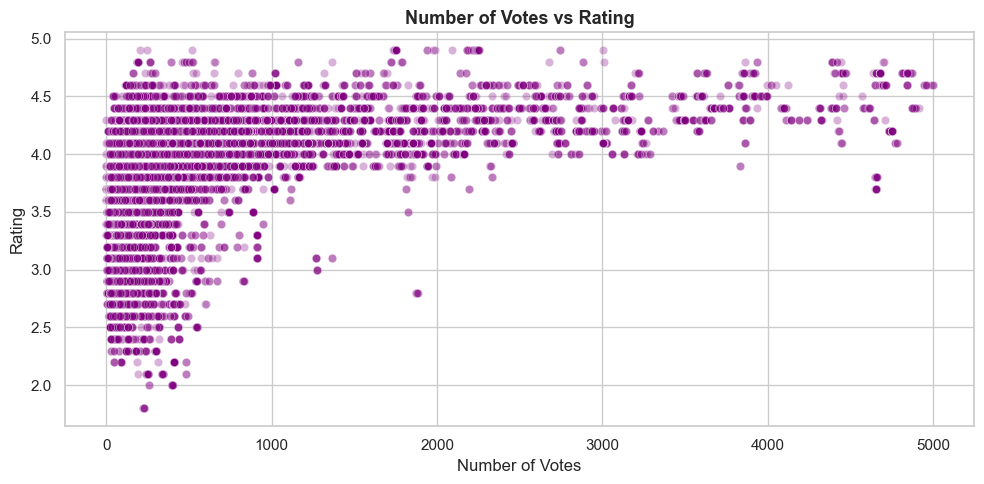

In [17]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='votes', y='rate', data=df[df['votes'] < 5000], alpha=0.3, color='purple')
plt.title('Number of Votes vs Rating', fontsize=13, fontweight='bold')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('votes_vs_rating.png', dpi=150)
plt.show()

## 🚨 Step 8: Outlier Detection

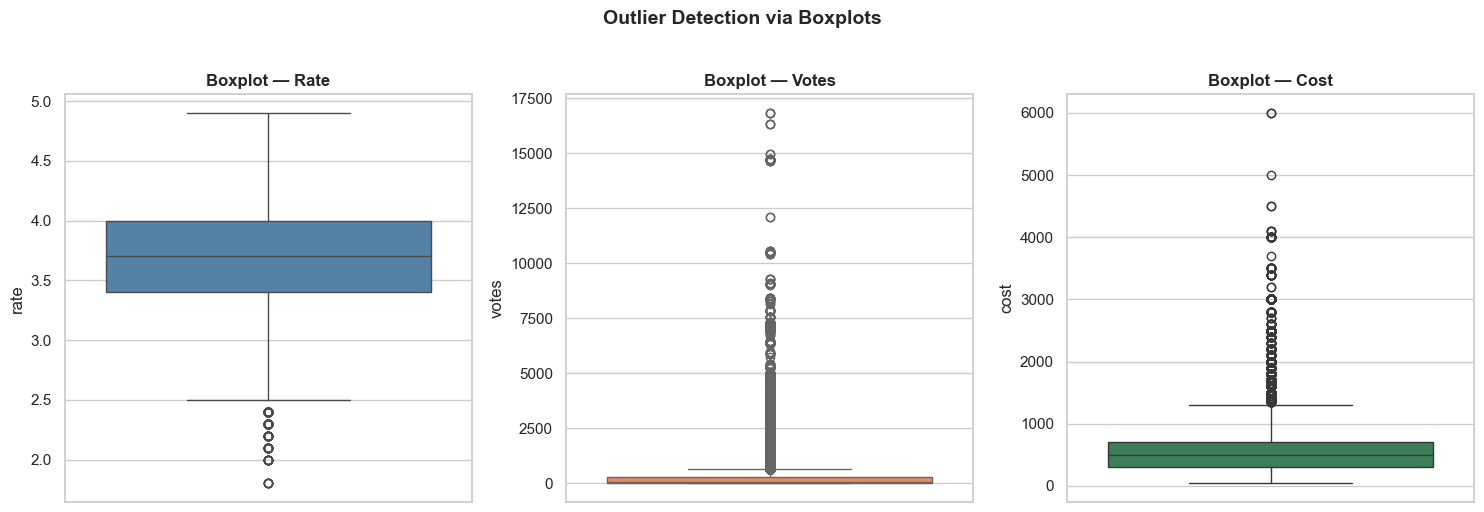

=== Outlier Count using IQR Method ===
rate       → 187 outliers (0.4% of data)
votes      → 5476 outliers (13.1% of data)
cost       → 3150 outliers (7.6% of data)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['rate', 'votes', 'cost'], ['steelblue', 'coral', 'seagreen']):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f'Boxplot — {col.capitalize()}', fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150)
plt.show()

# IQR Method
print("=== Outlier Count using IQR Method ===")
for col in ['rate', 'votes', 'cost']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col:10s} → {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}% of data)")

## 🏆 Step 9: Top & Bottom Restaurants

In [19]:
# Filter to restaurants with at least 50 votes for fairness
popular_df = df[df['votes'] >= 50]

print("=== Top 10 Highest Rated Restaurants ===")
top10 = popular_df.nlargest(10, 'rate')[['name', 'location', 'restaurant_type', 'rate', 'votes', 'cost']]
print(top10.to_string(index=False))

print("\n=== Top 10 Most Voted Restaurants ===")
most_voted = popular_df.nlargest(10, 'votes')[['name', 'location', 'rate', 'votes', 'cost']]
print(most_voted.to_string(index=False))

=== Top 10 Highest Rated Restaurants ===
                          name              location    restaurant_type  rate  votes   cost
   Byg Brewski Brewing Company         Sarjapur Road           Delivery   4.9  16345 1600.0
   Byg Brewski Brewing Company         Sarjapur Road           Dine-out   4.9  16345 1600.0
   Byg Brewski Brewing Company         Sarjapur Road Drinks & nightlife   4.9  16345 1600.0
        Belgian Waffle Factory          Brigade Road           Delivery   4.9   1746  400.0
        Belgian Waffle Factory          Brigade Road           Desserts   4.9   1746  400.0
                      Flechazo            Whitefield             Buffet   4.9   2745 1400.0
                  Punjab Grill            Whitefield           Delivery   4.9    518 2000.0
                      Flechazo            Whitefield           Dine-out   4.9   2745 1400.0
     AB's - Absolute Barbecues                   BTM             Buffet   4.9   6375 1600.0
Asia Kitchen By Mainland China Koramang

## 🍽️ Step 10: Cuisine Analysis

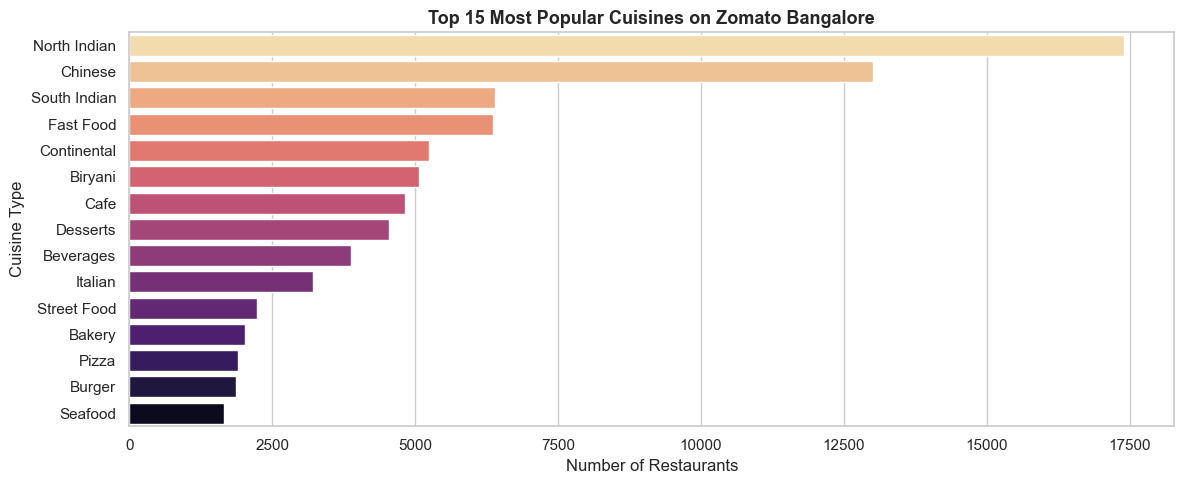

In [20]:
# Explode cuisines (each restaurant may serve multiple)
cuisine_df = df.copy()
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.split(', ')
cuisine_exploded = cuisine_df.explode('cuisines')

top_cuisines = cuisine_exploded['cuisines'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='magma_r')
plt.title('Top 15 Most Popular Cuisines on Zomato Bangalore', fontsize=13, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.savefig('top_cuisines.png', dpi=150)
plt.show()

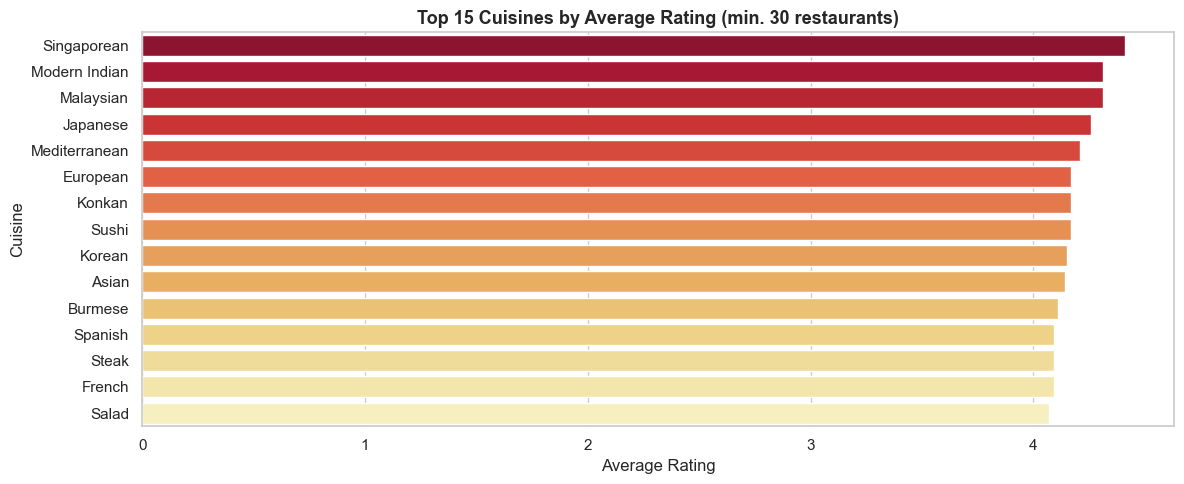

In [21]:
# Average rating per cuisine (min 30 restaurants)
cuisine_rating = cuisine_exploded.groupby('cuisines').agg(
    Count=('name', 'count'),
    Avg_Rating=('rate', 'mean')
).round(2)
cuisine_rating = cuisine_rating[cuisine_rating['Count'] >= 30].sort_values('Avg_Rating', ascending=False).head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=cuisine_rating['Avg_Rating'], y=cuisine_rating.index, palette='YlOrRd_r')
plt.title('Top 15 Cuisines by Average Rating (min. 30 restaurants)', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.savefig('cuisine_avg_rating.png', dpi=150)
plt.show()

## 📋 Step 11: Summary & Key Insights

After thorough analysis of the Zomato Bangalore dataset, here are the key takeaways:

### 🔑 Key Findings

1. **Rating Distribution**: Most restaurants are rated between **3.5 and 4.2**, showing a left-skewed distribution. Very few restaurants score below 3.0 or above 4.8.

2. **Online Orders**: Restaurants that offer **online ordering tend to have slightly higher ratings**, possibly due to greater customer reach and review volume.

3. **Table Booking**: Restaurants offering **table booking have noticeably higher average ratings**, suggesting they cater to a more premium dining experience.

4. **Cost vs Rating**: There is a **moderate positive correlation** between cost and rating — pricier restaurants tend to be rated better, but not always.

5. **Votes vs Rating**: More votes generally correspond to higher ratings, indicating that **popular restaurants maintain quality**.

6. **Location Matters**: Areas like **Indiranagar, Koramangala, and BTM** host the most restaurants, but top-rated ones are often found in premium zones.

7. **Cuisine Popularity**: **North Indian, Chinese, and Continental** are the most offered cuisines. However, **bakery and café** styles tend to score the highest average ratings.

### ✅ Conclusion
This analysis demonstrates how EDA and correlation studies can reveal actionable insights for a food-tech platform like Zomato — from understanding which restaurant types attract more engagement, to identifying cuisine preferences across Bangalore.